In [2]:
import ast
def read_dat(path):
    """Parse a .dat file whose lines look like:
       (p, l, k_min, k_max, [d0, d1, ...])
    Returns a list of (p, l, k_min, k_max, data) tuples."""
    entries = []
    with open(path) as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            try:
                p, l, k_min, k_max, data = ast.literal_eval(line)
            except (ValueError, SyntaxError) as e:
                raise ValueError(f"{path}:{lineno}: malformed line: {line!r}") from e
            entries.append((int(p), int(l), int(k_min), int(k_max), [float(x) for x in data]))
    return entries

#l=3

maximal_l_eq_2_filename = "l-2_maximal_bound-error.dat"
submaximal_index_p_l_eq_2_filename = "l-2_submaximal_index_p_bound-error.dat"
submaximal_index_q_l_eq_2_filename = "l-2_submaximal_index_q_q-eq-5_bound-error.dat"
submaximal_index_q2_l_eq_2_filename = "l-2_submaximal_index_q2_q-eq-5_bound-error.dat"
submaximal_index_p2_l_eq_2_filename = "l-2_submaximal_index_p2_bound-error.dat"

maximal_l_eq_2_array = read_dat(maximal_l_eq_2_filename);
submaximal_index_p_l_eq_2_array = read_dat(submaximal_index_p_l_eq_2_filename)
submaximal_index_q_l_eq_2_array = read_dat(submaximal_index_q_l_eq_2_filename)
submaximal_index_q2_l_eq_2_array = read_dat(submaximal_index_q2_l_eq_2_filename)
submaximal_index_p2_l_eq_2_array = read_dat(submaximal_index_p2_l_eq_2_filename)

#l=3

maximal_l_eq_3_filename = "l-3_maximal_bound-error.dat"
submaximal_index_p_l_eq_3_filename = "l-3_submaximal_index_p_bound-error.dat"
submaximal_index_q_l_eq_3_filename = "l-3_submaximal_index_q_q-eq-5_bound-error.dat"
submaximal_index_q2_l_eq_3_filename = "l-3_submaximal_index_q2_q-eq-5_bound-error.dat"
submaximal_index_p2_l_eq_3_filename = "l-3_submaximal_index_p2_bound-error.dat"

maximal_l_eq_3_array = read_dat(maximal_l_eq_3_filename);
submaximal_index_p_l_eq_3_array = read_dat(submaximal_index_p_l_eq_3_filename)
submaximal_index_q_l_eq_3_array = read_dat(submaximal_index_q_l_eq_3_filename)
submaximal_index_q2_l_eq_3_array = read_dat(submaximal_index_q2_l_eq_3_filename)
submaximal_index_p2_l_eq_3_array = read_dat(submaximal_index_p2_l_eq_3_filename)

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Line3DCollection

BLUE_RED = LinearSegmentedColormap.from_list("blue_red", ["#0d2be0", "#d40000"])


def plot_entries(entries, title=None, connect=False, ax=None,
                 save=None, dpi=150, close=False,
                 stems=False, stem_base=None, cmap=BLUE_RED,
                 vmin=None, vmax=None, colorbar=True, s=2,
                 elev_value=30, azim_value=-30, label_size=25):
    """3D plot: x = k, y = p, z = data value.
    Points and stems are colored by z, dark (low) to light (high).
    stems      -- draw a vertical segment from stem_base up to each point
    stem_base  -- z of the stem feet; None = global minimum (0.0 is often better)
    cmap       -- colormap or name;
    vmin/vmax  -- fix the color scale
    s          -- marker area for the scatter points
    elev_value -- elevation value for plot  # matplotlib's default is elev=30
    azim_value -- azimuthal angle for plot (spin around the z-axis) # matplotlib's default is azim=-60
    label_size -- font size of the axis labels (tick numbering is unaffected)
    save       -- path to write the figure to (e.g. "l3.png"); None to skip
    close      -- close the figure after saving, to avoid piling up memory
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(projection="3d")
    else:
        fig = ax.get_figure()

    cmap = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    ax.view_init(elev=elev_value, azim=-azim_value)

    all_z = np.concatenate([np.asarray(e[4], dtype=float) for e in entries])
    lo = all_z.min() if vmin is None else vmin
    hi = all_z.max() if vmax is None else vmax
    if lo == hi:                      # degenerate scale
        lo, hi = lo - 0.5, hi + 0.5
    norm = Normalize(vmin=lo, vmax=hi)

    if stem_base is None:
        stem_base = float(all_z.min())

    for p, l, k_min, k_max, data in entries:
        zs = np.asarray(data, dtype=float)
        ks = np.arange(k_min, k_min + len(zs))       # x
        pcol = np.full(len(ks), float(p))            # y
        cs = cmap(norm(zs))

        if stems:
            segs = [((k, y, stem_base), (k, y, z))
                    for k, y, z in zip(ks, pcol, zs)]
            ax.add_collection3d(
                Line3DCollection(segs, colors=cs, lw=0.6, alpha=0.5))

        if connect and len(zs) > 1:
            pts = np.column_stack([ks, pcol, zs])
            segs = np.stack([pts[:-1], pts[1:]], axis=1)
            mids = cmap(norm(0.5 * (zs[:-1] + zs[1:])))
            ax.add_collection3d(
                Line3DCollection(segs, colors=mids, lw=1.0, alpha=0.85))

        ax.scatter(ks, pcol, zs, c=cs, s=s, depthshade=False)

    # collections don't feed the autoscaler, so pin z by hand
    zlo = min(all_z.min(), stem_base)
    zhi = max(all_z.max(), stem_base)
    pad = 0.05 * (zhi - zlo) or 1.0
    ax.set_zlim(zlo - pad, zhi + pad)

    ax.set_xlabel("k", fontsize=label_size, labelpad=12)
    ax.set_ylabel("p", fontsize=label_size, labelpad=12)
    ax.set_zlabel("value", fontsize=label_size, labelpad=12)
    if title:
        ax.set_title(title)

    if colorbar:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.10)
        cb.set_label("value", size=label_size)

    if save is not None:
        fig.savefig(save, dpi=dpi, bbox_inches="tight")
        if close:
            plt.close(fig)

    return ax

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

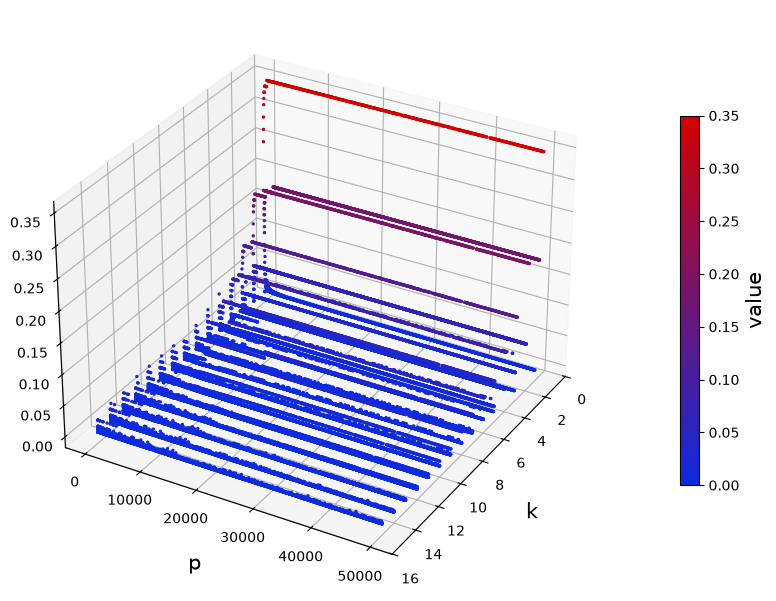

In [43]:
plot_entries(maximal_l_eq_2_array, save = "maximal_l-2.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

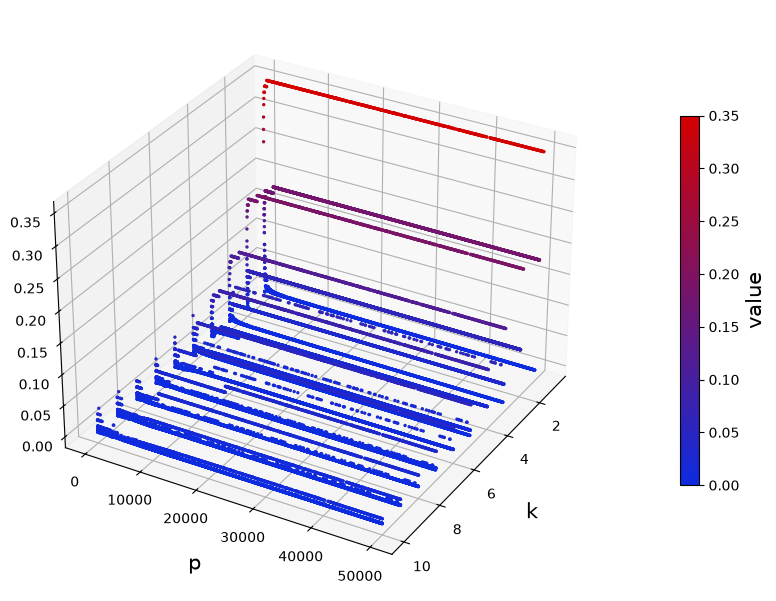

In [44]:
plot_entries(maximal_l_eq_3_array,  save = "maximal_l-3.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

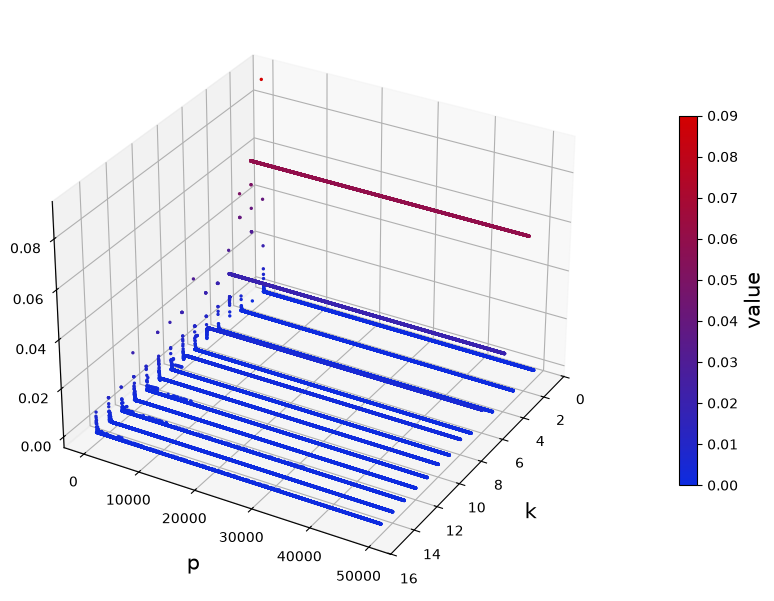

In [45]:
plot_entries(submaximal_index_p_l_eq_2_array,  save = "submaximal_index_p-l_2.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

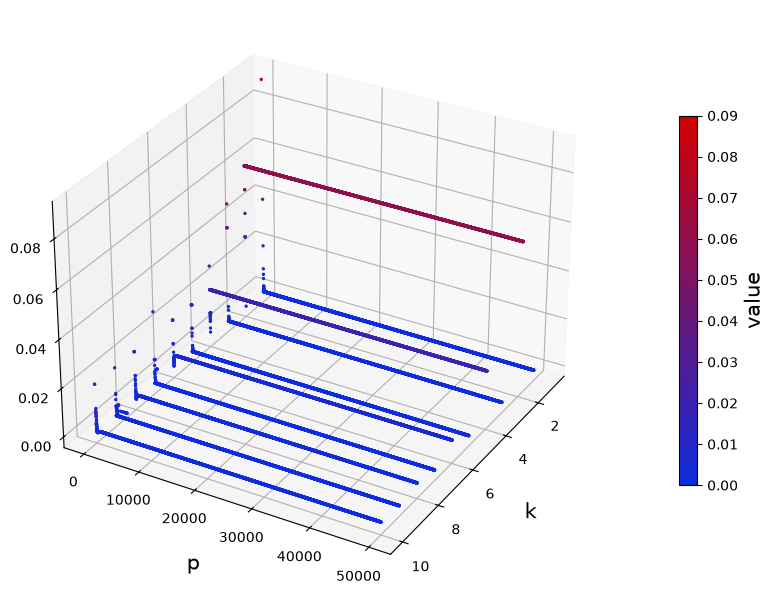

In [46]:
plot_entries(submaximal_index_p_l_eq_3_array,  save = "submaximal_index_p-l_3.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

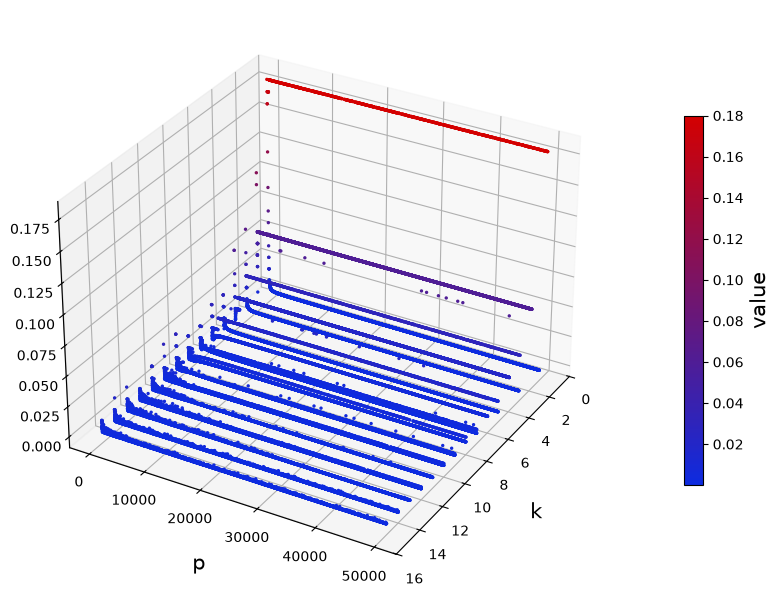

In [47]:
plot_entries(submaximal_index_q_l_eq_2_array,  save = "submaximal_index_q-l_2.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

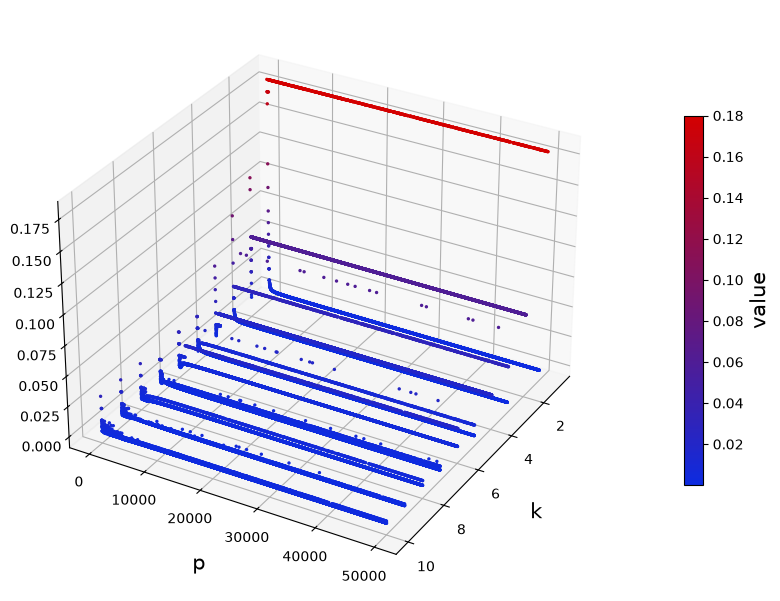

In [48]:
plot_entries(submaximal_index_q_l_eq_3_array,  save = "submaximal_index_q-l_3.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

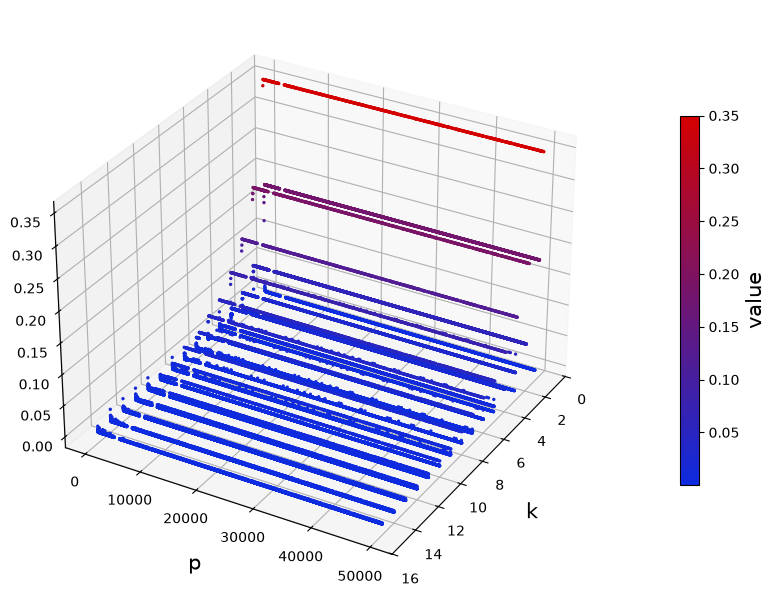

In [49]:
plot_entries(submaximal_index_q2_l_eq_2_array,  save = "submaximal_index_q2-l_2.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

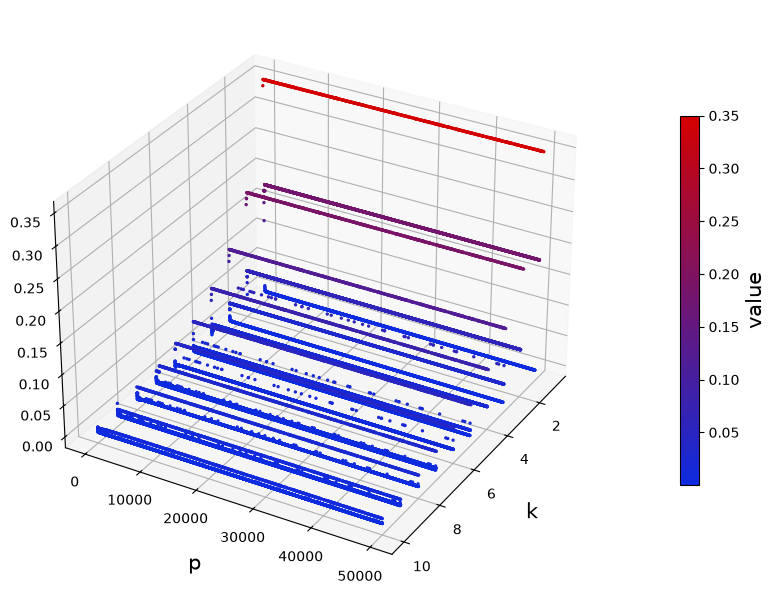

In [50]:
plot_entries(submaximal_index_q2_l_eq_3_array,  save = "submaximal_index_q2-l_3.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

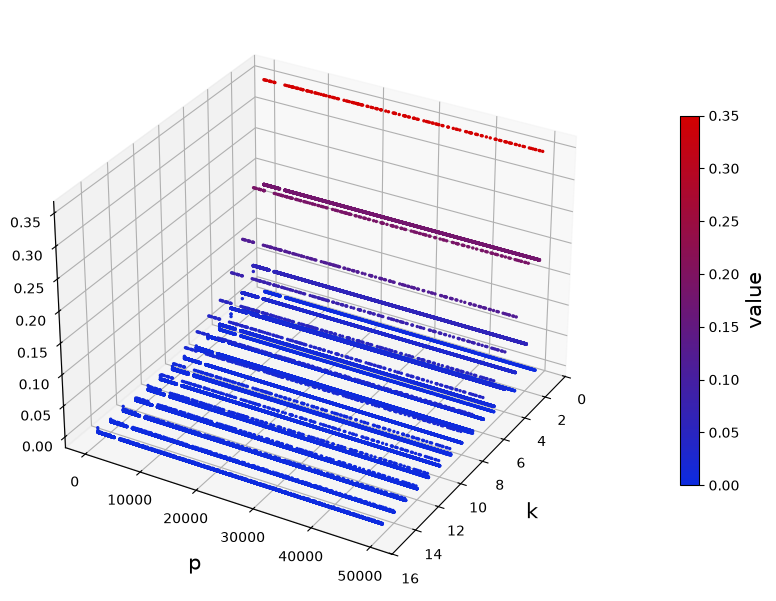

In [51]:
plot_entries(submaximal_index_p2_l_eq_2_array,  save = "submaximal_index_p2-l_2.pdf")

<Axes3D: xlabel='k', ylabel='p', zlabel='value'>

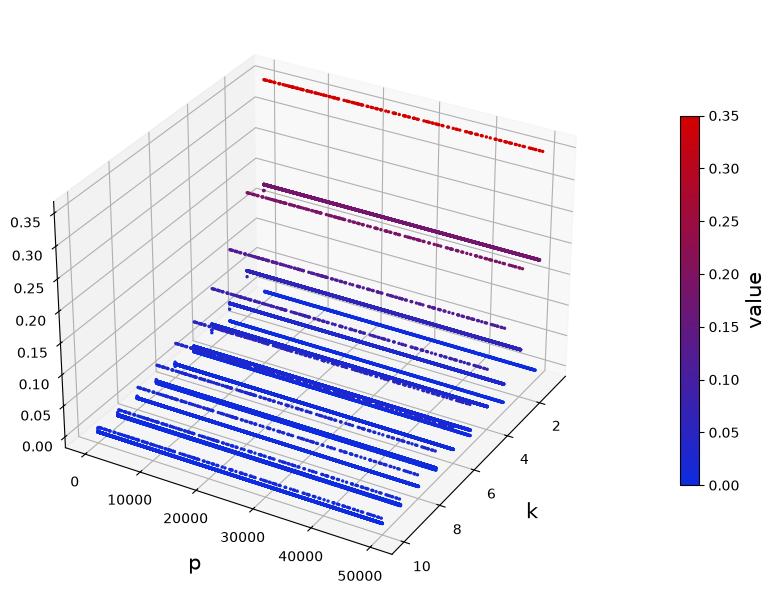

In [52]:
plot_entries(submaximal_index_p2_l_eq_3_array,  save = "submaximal_index_p2-l_3.pdf")